In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from datetime import datetime, timedelta
import logging
import sys
import os

project_root = os.path.dirname(os.getcwd())
sys.path.append(project_root)

from data.config.database import *
from data.utils.date_utils import *
from data.utils.preprocessing import *
from research.metrics import *
import seaborn as sns
import alphalens as al

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

# 配置日志
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

交易日历缓存已加载，共 13162 条记录


In [2]:
date_str = ','.join(f"'{date}'" for date in get_monthly_last_tradedate(engine,2016,2025))

In [3]:
daily_wide_query="""
select ts_code,trade_date,open,high,low,close,pre_close,is_st,is_suspend,circ_mv,total_mv,market,exchange,list_days,\
l1_code,l1_name,l2_code,l2_name,is_hs300,is_zz500,is_zz800,is_zz1000,is_zz2000
from stock_daily_wide 
where trade_date in ({})
""".format(date_str)

returns_query="""
select * from stock_forward_returns
where trade_date in ({})
""".format(date_str)

momentum_query="""
select ts_code, trade_date, tvr_mean_20, tvr_std_20, utr
from price_volume_20d
where trade_date in ({})
""".format(date_str)

trader_structure_query="""
select ts_code, trade_date, buy_sm_top10_ld, buy_sm_bottom10_ld, buy_elg_top10_ld, buy_elg_bottom10_ld
from trader_structure
where trade_date in ({})
""".format(date_str)

industry_resonance_query="""
select ts_code, trade_date, vm_ret_top5_ind_ret, vm_ret_top5_ind_ret_ld, vm_ret_bottom15_ind_ret, vm_ret_bottom15_ind_ret_ld
from industry_resonance
where trade_date in ({})
""".format(date_str)

high_low_spread_query="""
select ts_code, trade_date, close_top10_tvr_ld, close_bottom10_tvr_ld, close_top10_amp_ld, close_bottom10_amp_ld, tvr_mean_20, amp_mean_20
from high_low_spread
where trade_date in ({})
""".format(date_str)


In [4]:
df1=pd.read_sql_query(daily_wide_query,engine)
df2=pd.read_sql_query(returns_query,engine)
df3=pd.read_sql_query(momentum_query,engine)
df4=pd.read_sql_query(trader_structure_query,engine)
df5=pd.read_sql_query(industry_resonance_query,engine)
df6=pd.read_sql_query(high_low_spread_query,engine)

df=pd.merge(df1,df2,on=['ts_code','trade_date'],how='left')
df=pd.merge(df,df3,on=['ts_code','trade_date'],how='left')
df=pd.merge(df,df4,on=['ts_code','trade_date'],how='left')
df=pd.merge(df,df5,on=['ts_code','trade_date'],how='left')
df=pd.merge(df,df6,on=['ts_code','trade_date'],how='left')

In [5]:
df.columns = [str(col) for col in df.columns]
df=df[df.market!='北交所']
df=df[(df.list_days>=365)]
df=df[df.is_st.fillna(0)==0]
df=df[df.is_suspend.fillna(0)==0]
df=df[df.is_next_date_limit_up==0]
df['log_circ_mv']=np.log1p(df['circ_mv'])
df.rename(columns={"trade_date":"date","ts_code":"asset"},inplace=True)
df['date']=pd.to_datetime(df['date'])
df['year']=df['date'].dt.year
df=df.sort_values(by=['asset','date']).reset_index(drop=True)

In [6]:
def category(x):
    if x.is_hs300==1:
        return '1.沪深300'
    elif x.is_zz500==1:
        return '2.中证500'
    elif x.is_zz1000==1:
        return '3.中证1000'
    else:
        return '4.其他'

df['category']=df.apply(category,axis=1)

In [7]:
df['l1_code']=df['l1_code'].fillna('999.其他')

##baseline

In [8]:
df=df.sort_values(by=['date','asset']).set_index(['date','asset'])

多因子demo

In [14]:
df['utr_rev']=-df['utr']
df['buy_sm_cut_ret']=df['buy_sm_top10_ld']-df['buy_sm_bottom10_ld']
df['vm_ret_cut_ind_ret']=df['vm_ret_top5_ind_ret_ld']-df['vm_ret_bottom15_ind_ret_ld']
df['close_cut_amp']=df['close_bottom10_amp_ld']-df['close_top10_amp_ld']

In [15]:
factor_cols=['utr_rev', 'buy_sm_cut_ret', 'vm_ret_cut_ind_ret', 'close_cut_amp']

In [16]:
for col in factor_cols:
    df[col]=df.groupby(['date', 'l1_code'])[col].transform(lambda x: x.fillna(x.mean()))
    df[col+'_ne']=neutralize_factor(df,col)
    df[col+'_ne']=rank_factor(df,col+'_ne')

quick_factor_scan(df, [col+'_ne' for col in factor_cols], ['20D'])

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.7% entries from factor data: 0.7% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


,factor,return,group,ic_mean,icir_annual,ic_hit_ratio,ic_monotonicity,long_short_annual,long_short_sharpe,long_excess_annual,long_excess_ir
0,utr_rev_ne,20D,total,0.093472,4.083327,0.883333,0.987879,0.279333,2.600229,0.089476,2.078802
1,buy_sm_cut_ret_ne,20D,total,0.091447,3.591508,0.858333,1.000000,0.262035,2.021613,0.070517,1.640756
2,vm_ret_cut_ind_ret_ne,20D,total,0.049042,2.729473,0.791667,0.975758,0.171318,1.899599,0.063436,1.354547
3,close_cut_amp_ne,20D,total,0.071592,3.991582,0.875000,0.927273,0.189737,2.068536,0.032818,0.759999


In [56]:
quick_factor_scan(df, ['utr_rev_ne'], ['20D'], group_col='year')

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% en

,factor,return,group,ic_mean,icir_annual,ic_hit_ratio,ic_monotonicity,long_short_annual,long_short_sharpe,long_excess_annual,long_excess_ir
0,utr_rev_ne,20D,2016,0.131304,6.055994,1.000000,0.975758,0.422013,4.551210,0.186448,3.543848
1,utr_rev_ne,20D,2017,0.110801,7.213043,1.000000,0.672727,0.322207,5.618647,0.015098,0.766410
2,utr_rev_ne,20D,2018,0.083255,4.032373,0.833333,0.927273,0.340919,4.080356,0.104624,3.795006
3,utr_rev_ne,20D,2019,0.084474,3.194938,0.833333,0.563636,0.257723,1.873587,0.101585,3.544416
4,utr_rev_ne,20D,2020,0.107569,3.537859,0.833333,0.854545,0.280829,1.849413,0.055738,1.430206
5,utr_rev_ne,20D,2021,0.089003,4.278227,0.916667,0.745455,0.192412,1.644796,0.025482,0.553817
6,utr_rev_ne,20D,2022,0.070338,3.465265,0.833333,0.793939,0.209784,2.229624,0.066350,1.976973
7,utr_rev_ne,20D,2023,0.086520,3.869454,0.916667,0.381818,0.256668,2.865204,0.120779,2.531428
8,utr_rev_ne,20D,2024,0.066648,2.335636,0.750000,0.696970,0.254906,1.882559,0.093425,1.605942
9,utr_rev_ne,20D,2025,0.104805,5.056827,0.916667,0.842424,0.255872,2.309642,0.125231,2.384419


In [17]:
ics=get_merged_factor_ic(df, [col+'_ne' for col in factor_cols])

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.7% entries from factor data: 0.7% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


In [18]:
ics.corr()

,utr_rev_ne,buy_sm_cut_ret_ne,vm_ret_cut_ind_ret_ne,close_cut_amp_ne
utr_rev_ne,1.000000,0.847376,0.422983,0.695076
buy_sm_cut_ret_ne,0.847376,1.000000,0.160538,0.558696
vm_ret_cut_ind_ret_ne,0.422983,0.160538,1.000000,0.340932
close_cut_amp_ne,0.695076,0.558696,0.340932,1.000000


In [22]:
df['combined_factor']=df[['utr_rev_ne','buy_sm_cut_ret_ne','vm_ret_cut_ind_ret_ne','close_cut_amp_ne']].mean(axis=1)

In [23]:
quick_factor_scan(df, ['combined_factor'], ['20D'])

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


,factor,return,group,ic_mean,icir_annual,ic_hit_ratio,ic_monotonicity,long_short_annual,long_short_sharpe,long_excess_annual,long_excess_ir
0,combined_factor,20D,total,0.101763,4.439333,0.9,1.0,0.286249,2.595733,0.088986,2.150944


In [50]:
quick_factor_scan(df, ['combined_factor'], ['20D'], group_col='category')

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


,factor,return,group,ic_mean,icir_annual,ic_hit_ratio,ic_monotonicity,long_short_annual,long_short_sharpe,long_excess_annual,long_excess_ir
0,combined_factor,20D,1.沪深300,0.036109,1.238142,0.641667,0.393939,0.109689,0.661844,0.011947,0.163762
1,combined_factor,20D,2.中证500,0.060010,2.481337,0.758333,0.903030,0.131649,0.898023,0.047068,0.707452
2,combined_factor,20D,3.中证1000,0.100108,3.915862,0.866667,0.939394,0.254994,2.139531,0.104405,1.757385
3,combined_factor,20D,4.其他,0.122540,4.525954,0.916667,1.000000,0.365251,2.840337,0.097707,2.057014
4,combined_factor,20D,total,0.101763,4.439333,0.900000,1.000000,0.286249,2.595733,0.088986,2.150944


Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,0.000000,0.100167,0.049926,0.028905,44070,10.011927
2,0.099917,0.200256,0.150002,0.028874,44014,9.999205
3,0.199625,0.300518,0.250008,0.028869,44000,9.996024
4,0.299357,0.400277,0.350006,0.028865,44008,9.997842
5,0.399069,0.500370,0.450028,0.028881,44025,10.001704
6,0.498781,0.600299,0.550026,0.028860,43991,9.993980
7,0.598715,0.700469,0.650004,0.028862,43992,9.994207
8,0.698648,0.800277,0.750005,0.028876,44016,9.999659
9,0.799126,0.900288,0.850016,0.028865,43998,9.995570


Returns Analysis


,20D
Ann. alpha,0.087
beta,-0.045
Mean Period Wise Return Top Quantile (bps),74.563
Mean Period Wise Return Bottom Quantile (bps),-158.214
Mean Period Wise Spread (bps),232.778


2026-02-15 10:25:56,403 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-15 10:25:56,417 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Figure size 640x480 with 0 Axes>

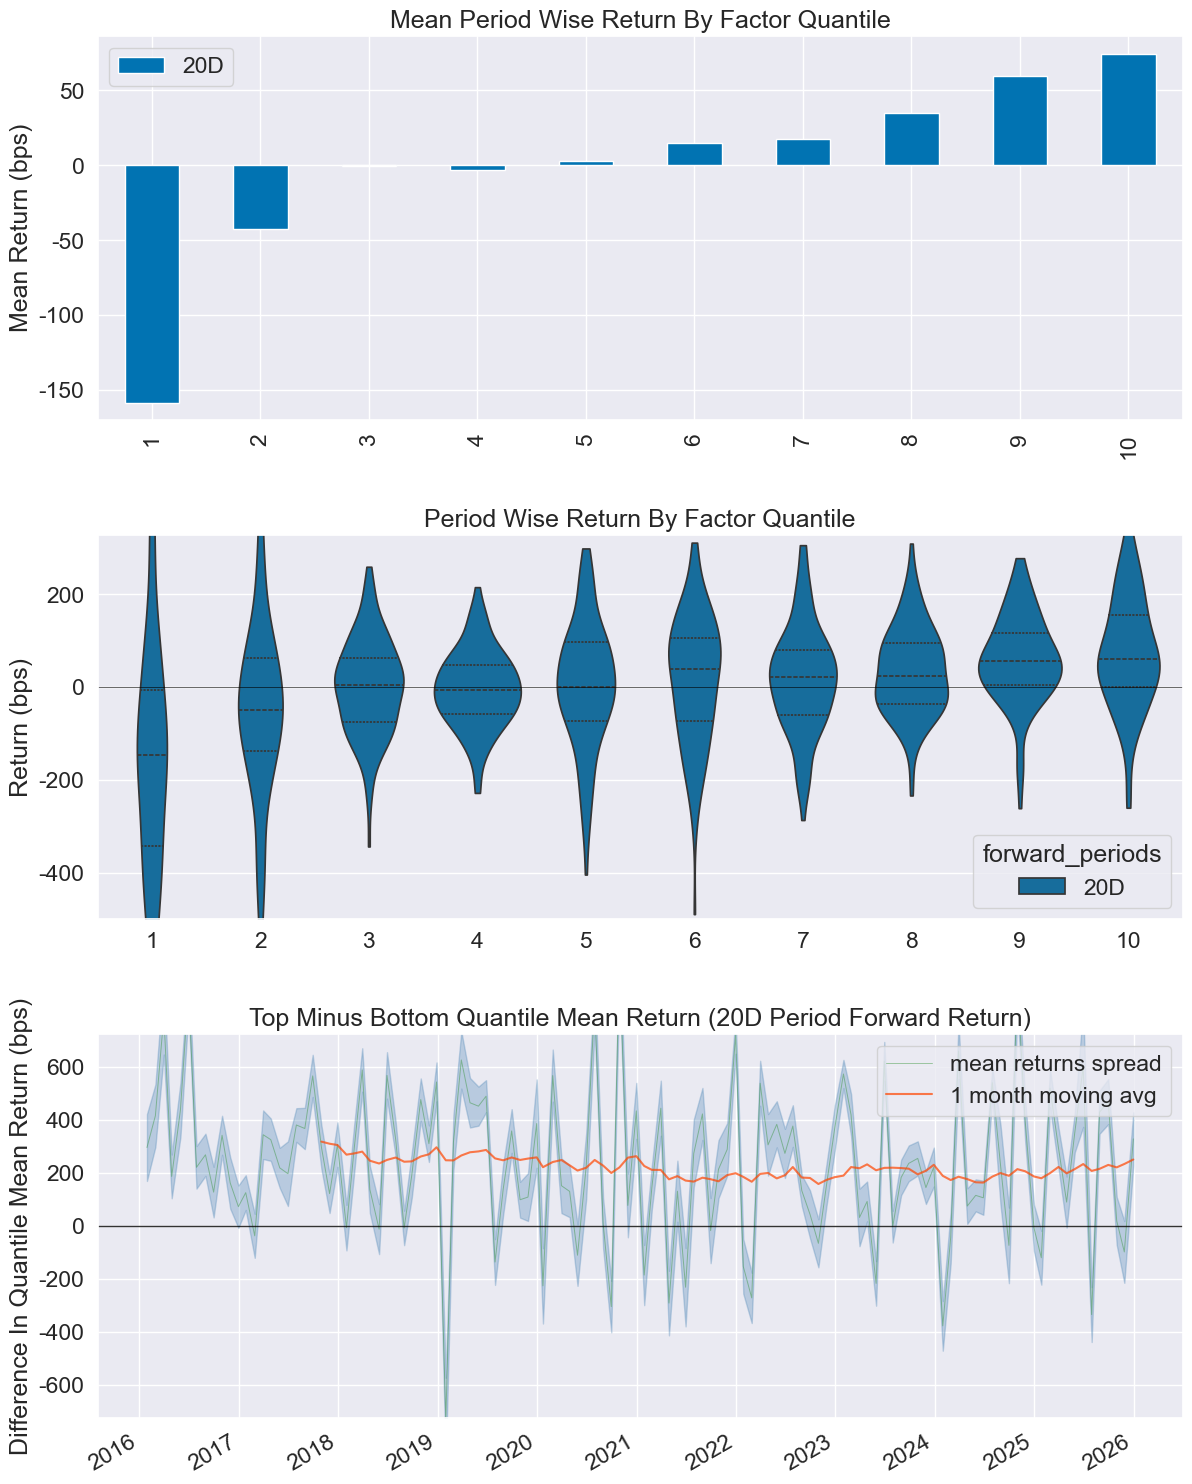

Information Analysis


,20D
IC Mean,0.093
IC Std.,0.079
Risk-Adjusted IC,1.179
t-stat(IC),12.913
p-value(IC),0.000
IC Skew,0.048
IC Kurtosis,0.241


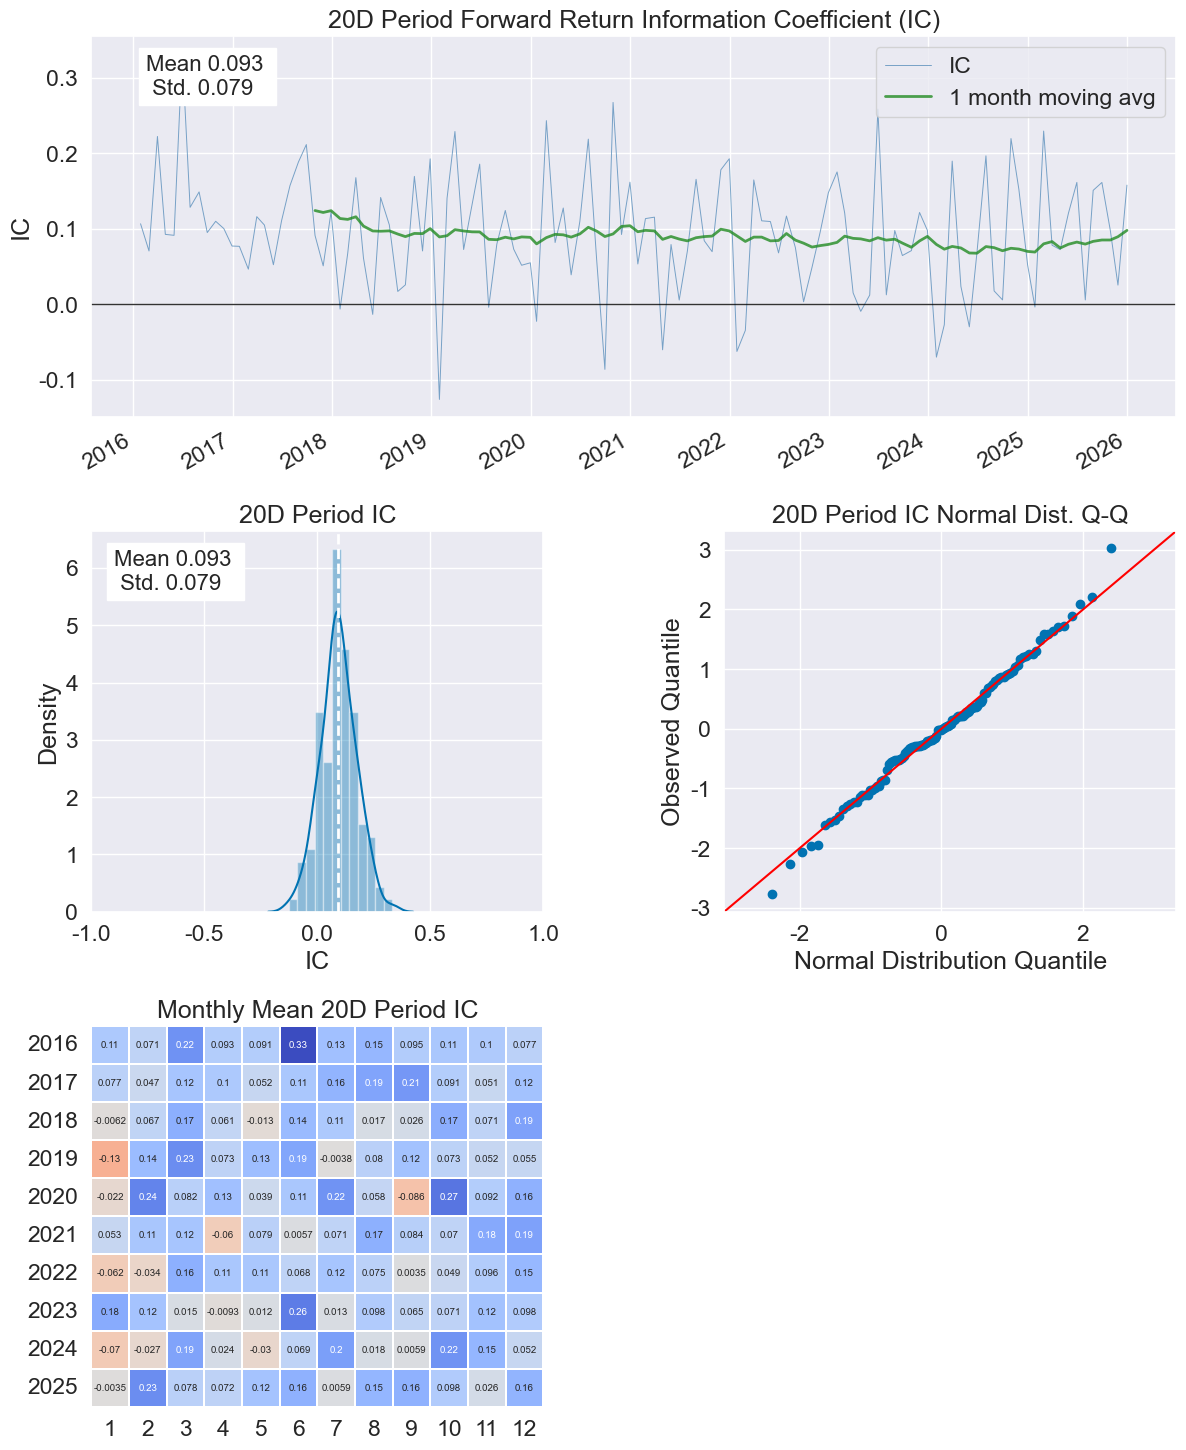

Turnover Analysis


,20D
Quantile 1 Mean Turnover,0.870
Quantile 2 Mean Turnover,0.891
Quantile 3 Mean Turnover,0.911
Quantile 4 Mean Turnover,0.901
Quantile 5 Mean Turnover,0.877
Quantile 6 Mean Turnover,0.887
Quantile 7 Mean Turnover,0.895
Quantile 8 Mean Turnover,0.901
Quantile 9 Mean Turnover,0.900
Quantile 10 Mean Turnover,0.882


,20D
Mean Factor Rank Autocorrelation,0.086


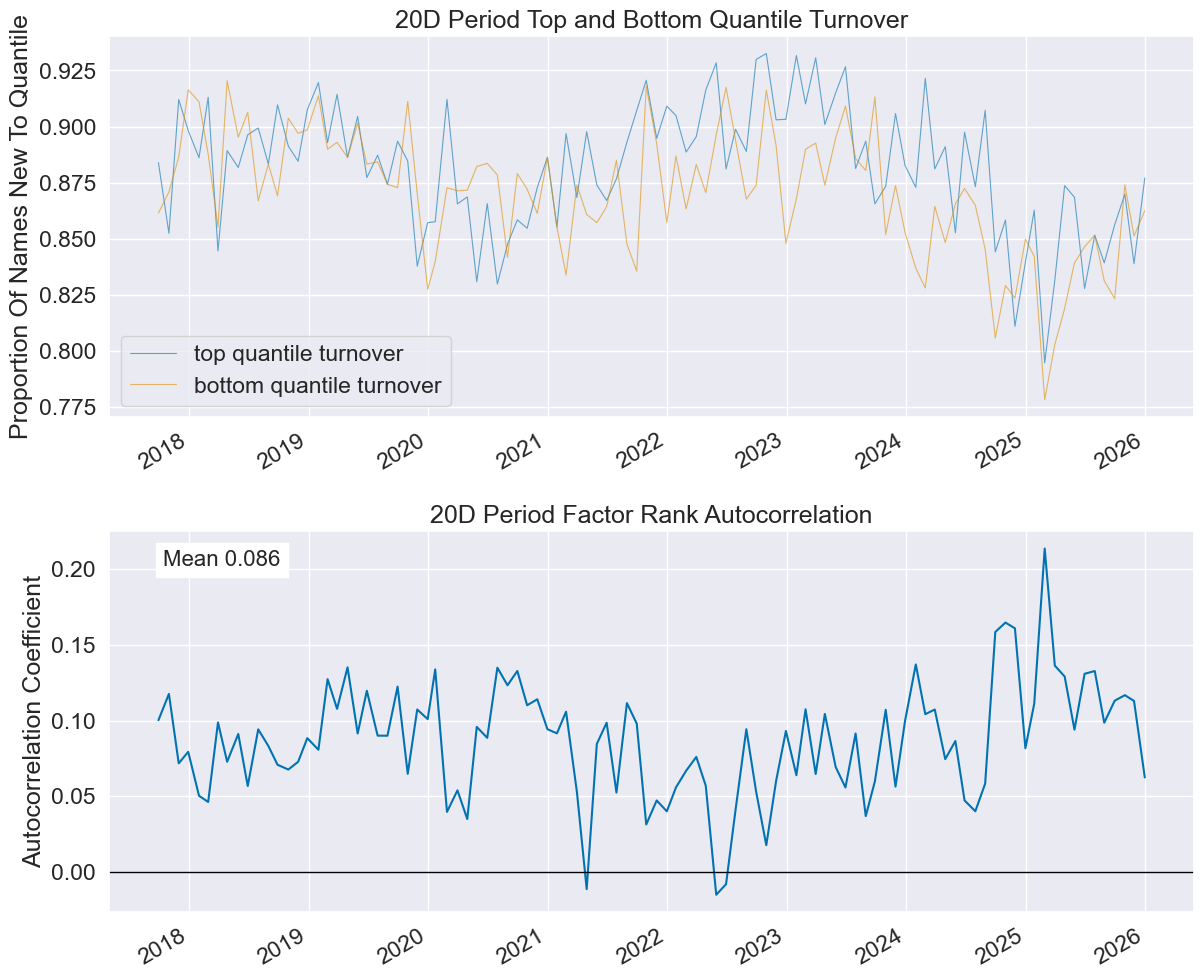

In [57]:
merged_data=al.utils.get_clean_factor(
    factor=df['utr_rev_ne'],
    forward_returns=df['20D'].to_frame(),
    quantiles=10
)

al.tears.create_full_tear_sheet(merged_data)

In [58]:
returns=merged_data.groupby(['date','factor_quantile'])['20D'].mean().unstack()
returns.head(10)

factor_quantile,1,2,3,4,5,6,7,8,9,10
date,,,,,,,,,,
2016-01-29,0.047370,0.050771,0.067494,0.068029,0.074515,0.086540,0.069116,0.076109,0.075711,0.077000
2016-02-29,0.145563,0.165592,0.164647,0.146603,0.129343,0.133330,0.131397,0.156199,0.164268,0.187198
2016-03-31,-0.012620,0.004389,0.010264,0.005683,0.012826,0.028643,0.028489,0.032729,0.043455,0.066647
2016-04-29,-0.065445,-0.039429,-0.053691,-0.047924,-0.041529,-0.043357,-0.036960,-0.032526,-0.031014,-0.046702
2016-05-31,0.036173,0.065251,0.059153,0.046799,0.040195,0.037165,0.035810,0.042789,0.056175,0.079941
2016-06-30,-0.069736,-0.059237,-0.027842,0.004160,0.019385,0.022251,0.017303,0.021972,0.021134,0.019482
2016-07-29,0.060318,0.066077,0.070569,0.049768,0.067942,0.066305,0.065892,0.071870,0.082442,0.082493
2016-08-31,-0.014216,-0.006988,0.000712,0.020897,0.005564,0.010052,0.009479,0.018996,0.016741,0.012686
2016-09-30,0.036073,0.038340,0.027604,0.021750,0.021214,0.026688,0.034683,0.030119,0.038142,0.048889


In [53]:
returns['ls']=returns[10]-returns[1]
cum_returns=(returns+1).cumprod()-1

<Axes: xlabel='date'>

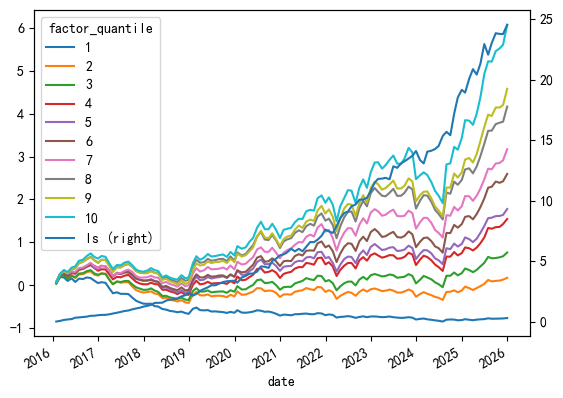

In [54]:
cum_returns.plot(secondary_y=['ls'])

In [116]:
# 看下按照tvr_std_20分布下的tvr_mean_20，发现稳定的组量越大越好，不稳定的组量越小越好
# df['dummy']=pd.cut(df['tvr_std_20_rk'],4,[1,2,3,4])
# result=quick_factor_scan(df,['tvr_mean_20','tvr_mean_20_desize','tvr_mean_20_ne'],['20D'],group_col='dummy')

In [117]:
# 复现U-turn法，使用原始因子、中性化因子分别测试
# 原始因子，即高子剑研报原文
bottom=(1-rank_factor(df[df.tvr_std_20_rk<0.5],'tvr_mean_20_rk'))*0.5
top=rank_factor(df[df.tvr_std_20_rk>=0.5],'tvr_mean_20_rk')*0.5
total=pd.concat([bottom,top],axis=0)
total=pd.DataFrame(total,columns=['tvr_mean_mod'])

df=pd.merge(df, total, left_index=True, right_index=True, how='left')
df['utr']=df['tvr_std_20_rk']+df['tvr_mean_mod']
df['utr_desize']=neutralize_factor(df,'utr',industry_col=None)
df['utr_ne']=neutralize_factor(df,'utr')

In [118]:
##改变一下，对中性化因子类似操作？
bottom=(1-rank_factor(df[df.tvr_std_20_ne_rk<0.5],'tvr_mean_20_ne'))*0.5
top=rank_factor(df[df.tvr_std_20_ne_rk>=0.5],'tvr_mean_20_ne')*0.5
total=pd.concat([bottom,top],axis=0)
total=pd.DataFrame(total,columns=['tvr_mean_ne_mod'])

df=pd.merge(df, total, left_index=True, right_index=True, how='left')
df['utr1']=df['tvr_std_20_ne_rk']+df['tvr_mean_ne_mod']
df['utr1_desize']=neutralize_factor(df,'utr1',industry_col=None)
df['utr1_ne']=neutralize_factor(df,'utr1')

In [120]:
##原始因子先合成，再中性化，多头收益高；先中性化，再合成，更稳定。追求多头收益先合成再中性化较好
quick_factor_scan(df,['tvr_std_20_ne','utr_ne','utr1_ne',],['20D'])

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


,factor,return,group,ic_mean,icir_annual,ic_hit_ratio,ic_monotonicity,long_short_annual,long_short_sharpe,long_excess_annual,long_excess_ir
0,tvr_std_20_ne,20D,total,-0.095818,-3.917728,0.866667,1.000000,0.253327,2.118379,0.072528,1.496167
1,utr_ne,20D,total,-0.094213,-3.983432,0.858333,0.987879,0.286991,2.628322,0.089194,2.093875
2,utr1_ne,20D,total,-0.091753,-4.293627,0.900000,0.987879,0.253782,2.646089,0.064364,1.838932


In [60]:
df.columns.tolist()

['open',
 'high',
 'low',
 'close',
 'pre_close',
 'is_st',
 'is_suspend',
 'circ_mv',
 'total_mv',
 'market',
 'exchange',
 'list_days',
 'l1_code',
 'l1_name',
 'l2_code',
 'l2_name',
 'is_hs300',
 'is_zz500',
 'is_zz800',
 'is_zz1000',
 'is_zz2000',
 'next_trade_date',
 'is_next_date_limit_up',
 '1D',
 '3D',
 '5D',
 '10D',
 '20D',
 '40D',
 '60D',
 '10D_vol',
 '20D_vol',
 '40D_vol',
 '60D_vol',
 'tvr_mean_20_x',
 'tvr_std_20',
 'utr',
 'buy_sm_top10_ld',
 'buy_sm_bottom10_ld',
 'buy_elg_top10_ld',
 'buy_elg_bottom10_ld',
 'vm_ret_top5_ind_ret',
 'vm_ret_top5_ind_ret_ld',
 'vm_ret_bottom15_ind_ret',
 'vm_ret_bottom15_ind_ret_ld',
 'close_top10_tvr_ld',
 'close_bottom10_tvr_ld',
 'close_top10_amp_ld',
 'close_bottom10_amp_ld',
 'tvr_mean_20_y',
 'amp_mean_20',
 'log_circ_mv',
 'year',
 'category',
 'buy_sm_cut_ret',
 'vm_ret_cut_ind_ret',
 'close_cut_amp',
 'utr_ne',
 'buy_sm_cut_ret_ne',
 'vm_ret_cut_ind_ret_ne',
 'close_cut_amp_ne',
 'utr_rev',
 'utr_rev_ne',
 'combined_factor']

<Axes: >

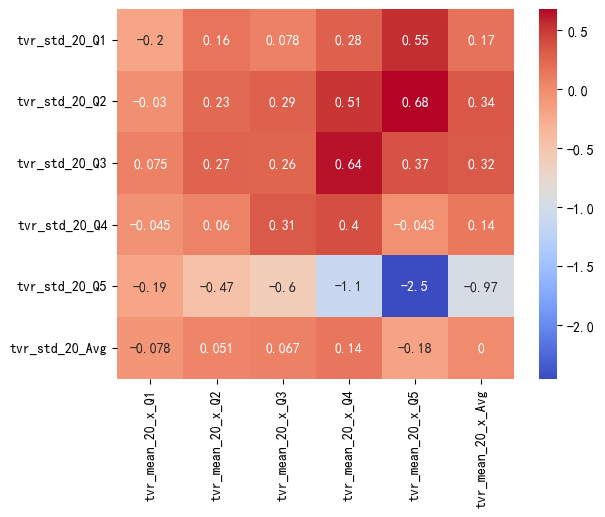

In [62]:
inter=calculate_factor_intersection_returns(df,'tvr_std_20','tvr_mean_20_x','20D',n_quantiles1=5,n_quantiles2=5,
                                           sequential=True)
sns.heatmap((inter['excess_return']*100).round(4),annot=True,cmap='coolwarm')

In [121]:
#对当天、20日上下影线差标准化
df['shadow_diff_rk_minus']=1-df['shadow_diff_rk']
df['shadow_diff_ne_rk_minus']=1-df['shadow_diff_ne_rk']
df['shadow_diff_mean_20_rk_minus']=1-df['shadow_diff_mean_20_rk']
df['shadow_diff_mean_20_ne_rk_minus']=1-df['shadow_diff_mean_20_ne_rk']

In [124]:
#先合成再中性化
df['tvr_plus1']=df['tvr_mean_20_rk']*df['shadow_diff_mean_20_rk_minus']
df['tvr_plus1']=neutralize_factor(df,'tvr_plus1')
df['tvr_plus2']=df[['tvr_mean_20_rk','shadow_diff_mean_20_rk_minus']].mean(axis=1)
df['tvr_plus2']=neutralize_factor(df,'tvr_plus2')

#先中性化再合成
df['tvr_plus3']=df['tvr_mean_20_ne_rk']*df['shadow_diff_mean_20_ne_rk_minus']
df['tvr_plus4']=df[['tvr_mean_20_ne_rk','shadow_diff_mean_20_ne_rk_minus']].mean(axis=1)

In [127]:
quick_factor_scan(df,['tvr_mean_20_ne_rk','tvr_std_20_ne_rk','tvr_plus1','tvr_plus2','tvr_plus3','tvr_plus4'],['20D'])

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 0.0% en

,factor,return,group,ic_mean,icir_annual,ic_hit_ratio,ic_monotonicity,long_short_annual,long_short_sharpe,long_excess_annual,long_excess_ir
0,tvr_mean_20_ne_rk,20D,total,-0.093927,-3.384665,0.808333,1.000000,0.244536,1.851965,0.060056,1.351553
1,tvr_std_20_ne_rk,20D,total,-0.095818,-3.917728,0.866667,1.000000,0.253327,2.118379,0.072528,1.496167
2,tvr_plus1,20D,total,-0.071913,-3.448795,0.866667,0.963636,0.257535,2.548724,0.056929,1.189257
3,tvr_plus2,20D,total,-0.081250,-3.293078,0.833333,0.963636,0.252117,2.155335,0.050702,1.086551
4,tvr_plus3,20D,total,-0.070754,-3.286966,0.825000,0.963636,0.266005,2.404577,0.055601,1.137917
5,tvr_plus4,20D,total,-0.082047,-3.488950,0.850000,0.987879,0.273392,2.256789,0.063096,1.405646


In [128]:
#对str类似处理
df['tvr_plus5']=df['tvr_std_20_rk']*df['shadow_diff_mean_20_rk_minus']
df['tvr_plus5']=neutralize_factor(df,'tvr_plus5')
df['tvr_plus6']=df[['tvr_std_20_rk','shadow_diff_mean_20_rk_minus']].mean(axis=1)
df['tvr_plus6']=neutralize_factor(df,'tvr_plus6')

#先中性化再合成
df['tvr_plus7']=df['tvr_std_20_ne_rk']*df['shadow_diff_mean_20_ne_rk_minus']
df['tvr_plus8']=df[['tvr_std_20_ne_rk','shadow_diff_mean_20_ne_rk_minus']].mean(axis=1)

In [132]:
evaluate_factor_combinations(df,['tvr_mean_20_ne_rk','tvr_std_20_ne_rk','utr_ne','utr1_ne'],['20D'],2)

开始评估 4 个因子的 2 组合
总组合数: 6
因子列表: ['tvr_mean_20_ne_rk', 'tvr_std_20_ne_rk', 'utr_ne', 'utr1_ne']
--------------------------------------------------
正在评估组合 1/6: ['tvr_mean_20_ne_rk', 'tvr_std_20_ne_rk']
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
正在评估组合 2/6: ['tvr_mean_20_ne_rk', 'utr_ne']
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
正在评估组合 3/6: ['tvr_mean_20_ne_rk', 'utr1_ne']
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
正在评估组合 4/6: ['tvr_std_20_ne_rk', 'utr_ne']
Dropped 0.0% entries from factor data: 0.0% in forward returns computation and

,combo_factors,return,group,ic_mean,icir_annual,ic_hit_ratio,ic_monotonicity,long_short_annual,long_short_sharpe,long_excess_annual,long_excess_ir
4,"tvr_std_20_ne_rk,utr1_ne",20D,total,-0.094012,-4.187492,0.891667,0.987879,0.269932,2.611497,0.081092,1.927314
5,"utr_ne,utr1_ne",20D,total,-0.094313,-4.188253,0.875000,0.987879,0.281984,2.673471,0.087464,2.205574
2,"tvr_mean_20_ne_rk,utr1_ne",20D,total,-0.094471,-4.096199,0.891667,0.987879,0.271227,2.510607,0.080331,1.763474
3,"tvr_std_20_ne_rk,utr_ne",20D,total,-0.095664,-3.970560,0.866667,0.975758,0.284470,2.542142,0.088455,2.011785
1,"tvr_mean_20_ne_rk,utr_ne",20D,total,-0.095732,-3.878210,0.858333,1.000000,0.288317,2.461844,0.090112,2.000792
0,"tvr_mean_20_ne_rk,tvr_std_20_ne_rk",20D,total,-0.096931,-3.652280,0.850000,0.987879,0.254773,2.006960,0.065009,1.450660


In [133]:
df['tvr_factor']=1-df[['tvr_mean_20_ne','utr_ne']].mean(axis=1)

<Axes: >

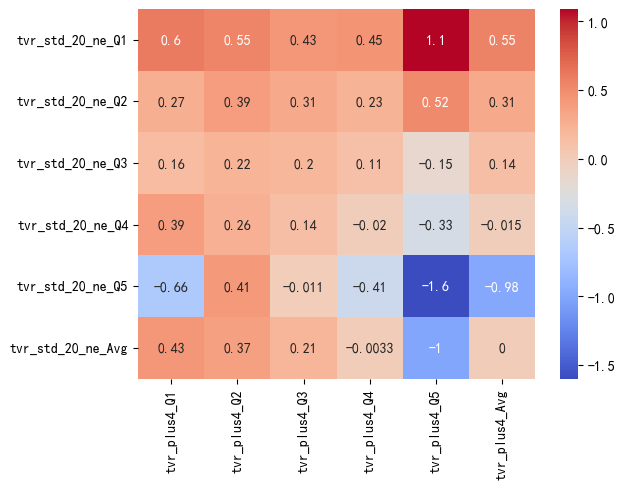

In [113]:
##看一下shadow_diff（单日/20日平均）对换手率的改良作用
inter=calculate_factor_intersection_returns(df,'tvr_std_20_ne','tvr_plus4','20D',n_quantiles1=5,n_quantiles2=5,
                                           sequential=False)
sns.heatmap((inter['excess_return']*100).round(4),annot=True,cmap='coolwarm')

In [142]:
df.index.get_level_values('date')

DatetimeIndex(['2016-01-29', '2016-01-29', '2016-01-29', '2016-01-29',
               '2016-01-29', '2016-01-29', '2016-01-29', '2016-01-29',
               '2016-01-29', '2016-01-29',
               ...
               '2025-12-31', '2025-12-31', '2025-12-31', '2025-12-31',
               '2025-12-31', '2025-12-31', '2025-12-31', '2025-12-31',
               '2025-12-31', '2025-12-31'],
              dtype='datetime64[ns]', name='date', length=440301, freq=None)

Dropped 0.4% entries from factor data: 0.4% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,0.000240,0.691498,0.376372,0.147250,87758,20.015372
2,0.466806,0.929960,0.732928,0.093657,87683,19.998267
3,0.829223,1.205451,1.002109,0.074092,87671,19.995530
4,1.074961,1.492745,1.263588,0.091714,87667,19.994617
5,1.286235,1.999794,1.625782,0.151034,87674,19.996214


Returns Analysis


,20D
Ann. alpha,0.050
beta,-0.074
Mean Period Wise Return Top Quantile (bps),29.028
Mean Period Wise Return Bottom Quantile (bps),-45.138
Mean Period Wise Spread (bps),74.167


2026-02-08 16:47:46,767 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-08 16:47:46,784 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Figure size 640x480 with 0 Axes>

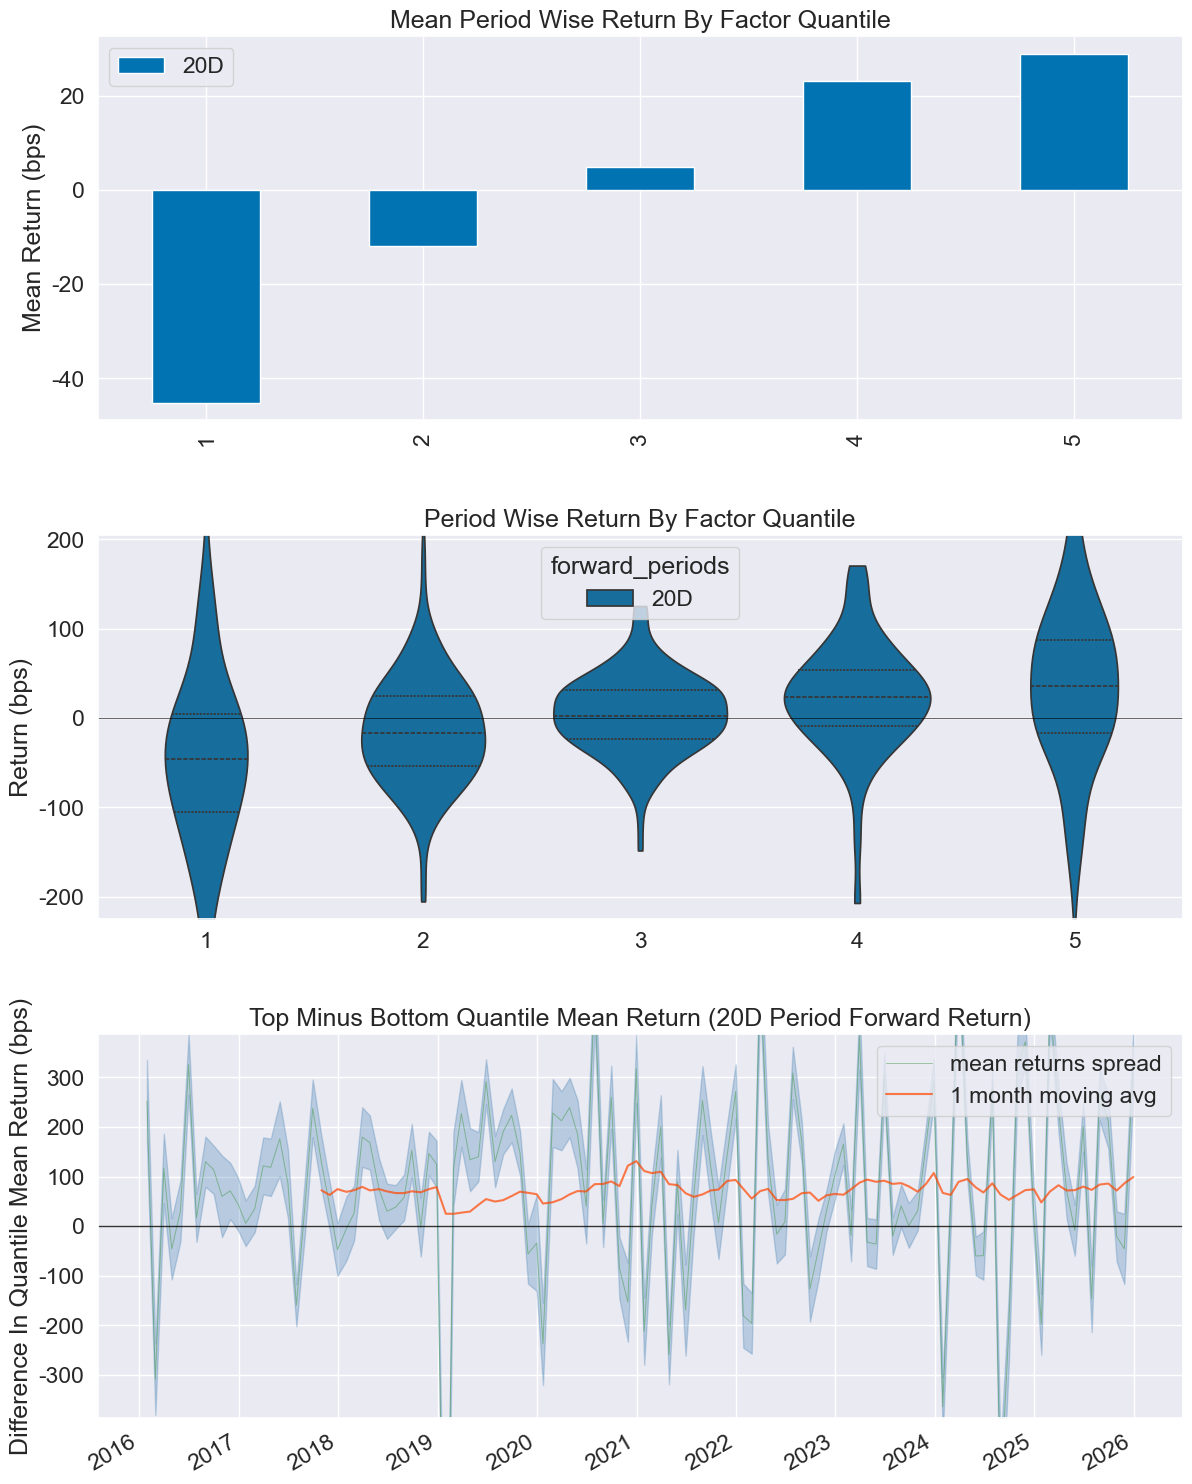

Information Analysis


,20D
IC Mean,0.051
IC Std.,0.067
Risk-Adjusted IC,0.751
t-stat(IC),8.221
p-value(IC),0.000
IC Skew,-0.530
IC Kurtosis,1.565


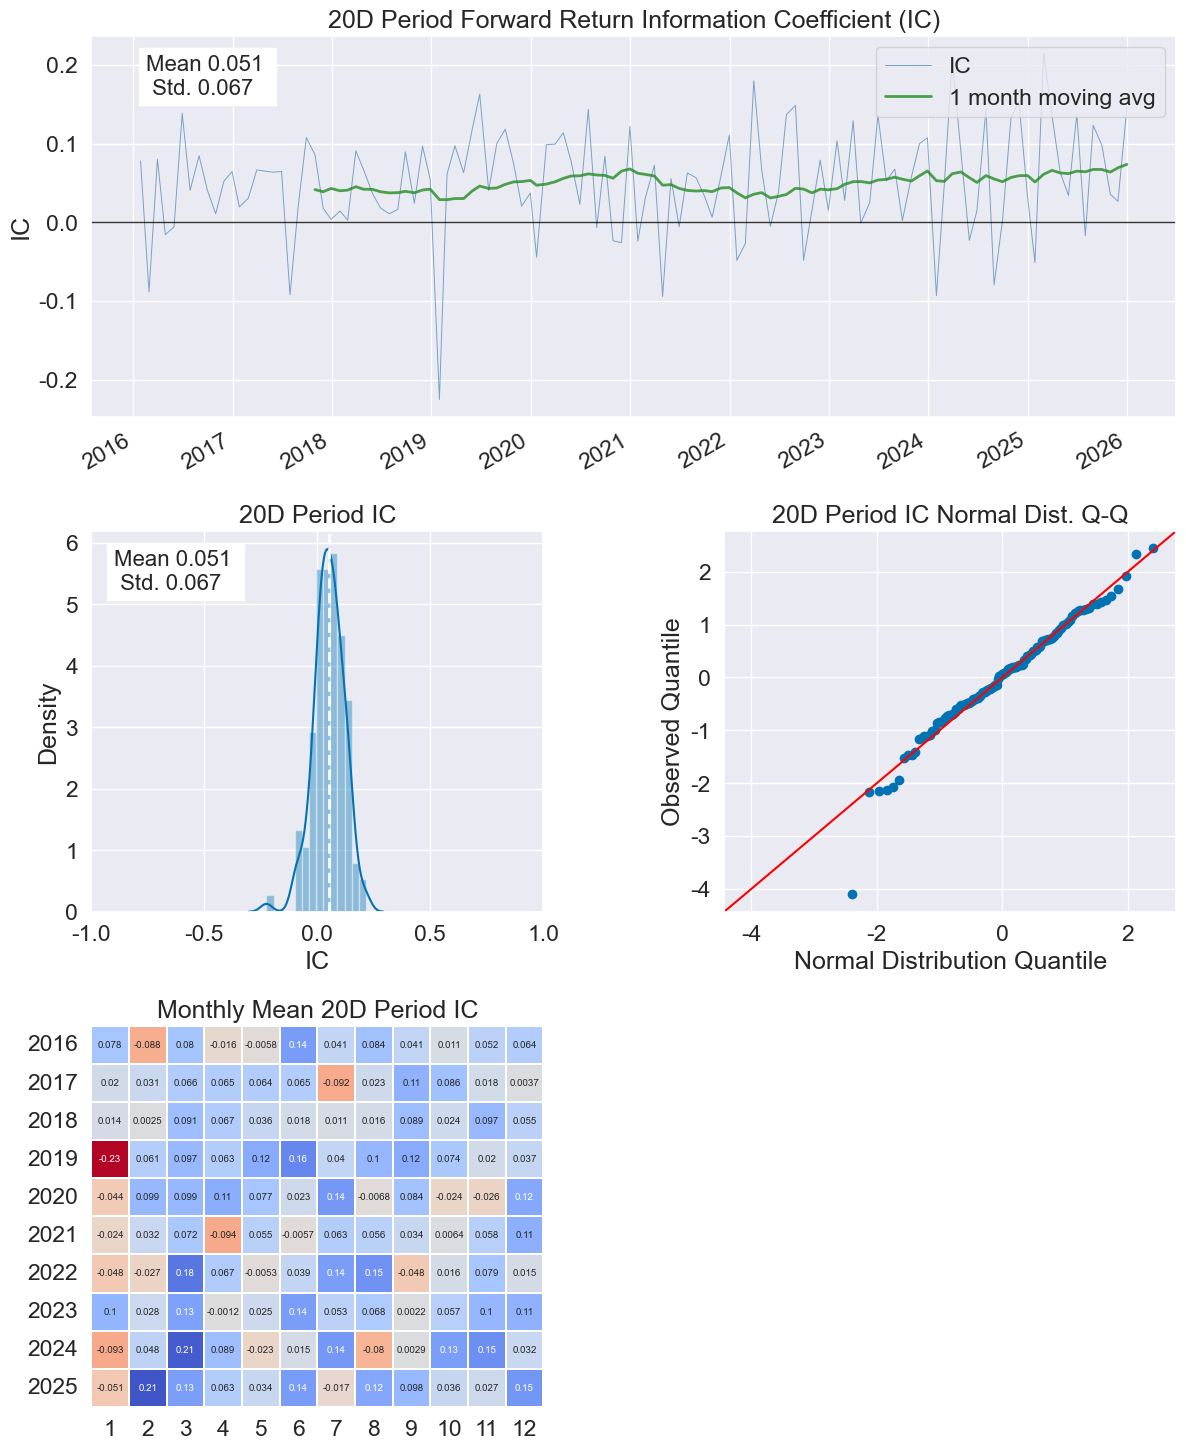

Turnover Analysis


,20D
Quantile 1 Mean Turnover,0.750
Quantile 2 Mean Turnover,0.814
Quantile 3 Mean Turnover,0.831
Quantile 4 Mean Turnover,0.819
Quantile 5 Mean Turnover,0.747


,20D
Mean Factor Rank Autocorrelation,0.231


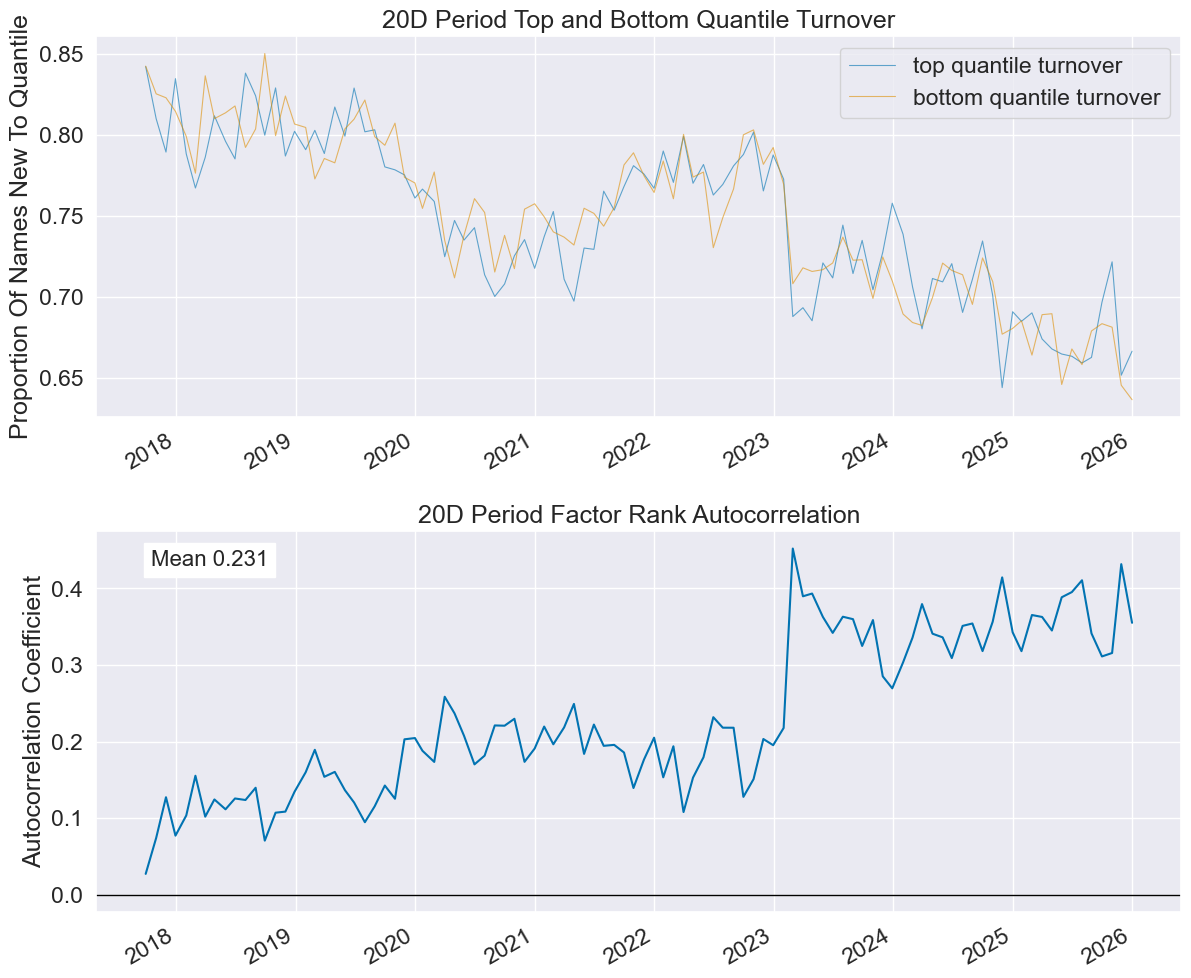

In [210]:
merged_data=al.utils.get_clean_factor(
    factor=df[df.index.get_level_values('date')>=pd.to_datetime('2016-01-01')]['test4'],
    forward_returns=df[df.index.get_level_values('date')>=pd.to_datetime('2016-01-01')]['20D'].to_frame(),
    quantiles=5
)

al.tears.create_full_tear_sheet(merged_data)

In [221]:
returns=merged_data.groupby(['date','factor_quantile'])['20D'].mean().unstack()
returns['long_short']=returns[5]-returns[1]
returns=returns[returns.index>=pd.to_datetime('2021-01-01')]

In [222]:
returns=(1+returns).cumprod()

<Axes: xlabel='date'>

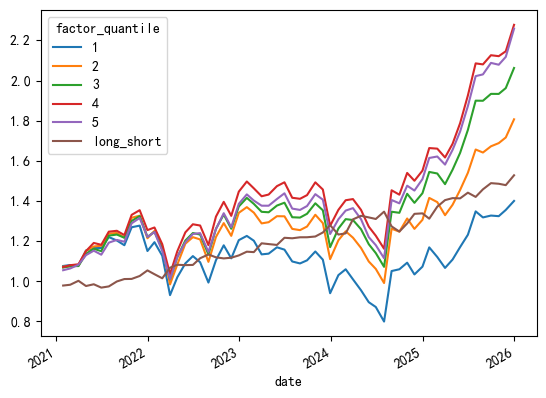

In [223]:
returns.plot()